# 🌡️ Part 2 — Climate Anomaly Detection & MoMD Algorithms

## Overview — input, output, và vai trò từng phần

| # | Section | Input | Output | Vai trò |
|---|---|---|---|---|
| 2.1 | Z-score + lag | `climate_weekly.parquet` | `merged`, `anomaly_cols`, `EXTREME_THRESHOLD` | **Pipeline backbone** — mọi section đều cần |
| 2.2 | Shingling | `merged` | `shingle_sets` | Chuỗi Ch.3 → cần cho 2.3 |
| 2.3 | MinHash | `shingle_sets` | `signatures` | Chuỗi Ch.3 → cần cho 2.4 |
| 2.4 | LSH Banding | `signatures` | `similar_pairs` | Chuỗi Ch.3 → output file |
| 2.5 | SVD modes | `merged` | `svd_static`, `svd_time`, `loadings` | **Pipeline feature** → Part 4 |
| 2.6 | PCY | `merged` | `pcy_feature` | **Pipeline feature** → Part 4 |
| 2.7 | Visualization + Export | tất cả | `part2_extended_features.parquet` | **Pipeline output** |

**Dependency:**
```
climate_weekly → 2.1 → 2.2 → 2.3 → 2.4 ──────────────────────────── similar_pairs (output)
                   │
                   ├── 2.5 (SVD) ──────────────────────────────────── svd features
                   └── 2.6 (PCY) ──────────────────────────────────── pcy feature
                                                                          │
                                                              2.7 Export → Part 4
```

**Outputs sang Part 4 (qua `part2_extended_features.parquet`):**
- `pcy_partner_extreme_count` — Ch.6: số nước co-extreme đang hoạt động tuần này
- `mode_1..mode_K` — Ch.11 SVD: climate fingerprint tĩnh của từng nước
- `mode_k_contrib` — Ch.11 SVD: đóng góp mode theo từng tuần

**Original outputs (giữ nguyên):**
- `climate_anomaly_features.parquet` — z-score + lag (pipeline gốc)
- `climate_similarity_pairs.parquet` — cặp nước giống nhau (MinHash)


In [12]:
!pip install pyarrow matplotlib seaborn bitarray scipy -q

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import hashlib, math, time
from collections import defaultdict, Counter
from itertools import combinations
import warnings; warnings.filterwarnings('ignore')

CLIMATE_IN = '/kaggle/input/notebooks/phongngtun/merge-data/climate_weekly.parquet'
FLUNET_IN  = '/kaggle/input/notebooks/phongngtun/merge-data/flunet_clean.parquet'
OUTPUT_DIR = '/kaggle/working/'

# ── Plot style ───────────────────────────────────────────────────
PLOT_BG = '#f8f8f6'
plt.rcParams.update({
    'figure.facecolor': PLOT_BG, 'axes.facecolor': PLOT_BG,
    'axes.edgecolor': '#333', 'axes.grid': True, 'grid.alpha': 0.25,
    'font.size': 10,
})

df = pd.read_parquet(CLIMATE_IN)
CLIM_VARS = [c for c in ['temperature_c','relative_humidity','precipitation_mm'] if c in df.columns]
print(f'Climate: {df.shape} | Variables: {CLIM_VARS}')

flu = pd.read_parquet(FLUNET_IN)
flu['flu_cases_total'] = pd.to_numeric(flu.get('flu_cases_total', 0), errors='coerce').fillna(0)
print(f'FluNet:  {flu.shape} | Years: {sorted(flu["year"].unique())}')

SEED = 42
np.random.seed(SEED)


Climate: (202740, 10) | Variables: ['temperature_c', 'relative_humidity', 'precipitation_mm']
FluNet:  (135870, 6) | Years: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 2.1 Climate Anomaly (Z-score) + Lag Features  *(pipeline)*

Baseline (đường nền): mean & std per `(country, ISO-week)` across all years available.
Z-score: $z = (x - \mu) / \sigma$. Lag features 1–4 weeks because flu lags climate by ~2 weeks.

We also derive `EXTREME_THRESHOLD` data-driven (90th percentile of |anomaly|) — robust regardless
of how many years are in the dataset.

In [14]:
# Baseline: mean & std per (country, iso_week) across all years
baseline = (
    df.groupby(['country_iso3','week'])[CLIM_VARS]
    .agg(['mean','std']).reset_index()
)
baseline.columns = ['_'.join(c).strip('_') for c in baseline.columns.values]

merged = (df
    .drop(columns=[c for c in df.columns if c.endswith('_mean') or c.endswith('_std')], errors='ignore')
    .merge(baseline, on=['country_iso3','week'], how='left'))

anomaly_cols = []
for v in CLIM_VARS:
    z = f'{v}_anomaly'
    merged[z] = (merged[v] - merged[f'{v}_mean']) / merged[f'{v}_std'].replace(0, np.nan)
    anomaly_cols.append(z)

merged['climate_stress_index'] = merged[anomaly_cols].pow(2).mean(axis=1).pow(0.5)

merged = merged.sort_values(['country_iso3','year','week']).reset_index(drop=True)
lag_cols = []
for col in anomaly_cols + ['climate_stress_index']:
    for lag in [1, 2, 3, 4]:
        lc = f'{col}_lag{lag}'
        merged[lc] = merged.groupby('country_iso3')[col].shift(lag)
        lag_cols.append(lc)

# Data-driven extreme threshold
_abs_anom = merged['temperature_c_anomaly'].abs().dropna()
EXTREME_THRESHOLD = float(_abs_anom.quantile(0.90))

print(f'Anomaly features : {len(anomaly_cols)} | Lag features: {len(lag_cols)}')
print(f'Extreme threshold (90th pct of |temp anomaly|): {EXTREME_THRESHOLD:.3f}')
print(f'  → {(_abs_anom > EXTREME_THRESHOLD).mean():.1%} of records flagged extreme')


ANOM_COL = 'temperature_c_anomaly'  # primary anomaly column used by downstream sections

Anomaly features : 3 | Lag features: 16
Extreme threshold (90th pct of |temp anomaly|): 1.607
  → 10.0% of records flagged extreme


## 2.2 Shingling — Convert Time Series to Sets  *(Ch.3)*

To apply MinHash/Jaccard on time series, treat each country's anomaly sequence as a document
and convert it to a set of k-shingles. Two countries with many shared shingles have similar
discretized climate dynamics.

In [49]:
def build_shingle_sets(df, anomaly_col, k=3, n_bins=10):
    shingle_sets = {}
    for country, grp in df.groupby('country_iso3'):
        series = grp.sort_values(['year','week'])[anomaly_col].dropna().values
        if len(series) < k + 1:
            continue
        try:
            bins = pd.qcut(series, q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            bins = pd.cut(series, bins=n_bins, labels=False)

        bins = [int(x) for x in bins]

        shingles = set()
        for i in range(len(bins) - k + 1):
            shingle = tuple(bins[i:i+k])
            shingles.add(str(shingle))
        shingle_sets[country] = shingles
    return shingle_sets

target_col = anomaly_cols[0]
shingle_sets = build_shingle_sets(merged, target_col, k=3, n_bins=10)
print(f'Countries with shingle sets: {len(shingle_sets)}')
sample = list(shingle_sets.keys())[0]
print(f'Example ({sample}): {len(shingle_sets[sample])} shingles')
# Kiểm tra số shingles thực tế
sizes = [len(v) for v in shingle_sets.values()]
print(f'Shingle set sizes — min: {min(sizes)}, max: {max(sizes)}, mean: {np.mean(sizes):.1f}')

Countries with shingle sets: 155
Example (AFG): 663 shingles
Shingle set sizes — min: 476, max: 712, mean: 639.2


## 2.3 MinHash Signatures from Scratch  *(Ch.3)*

Universal hash family $h_{a,b}(x) = ((ax+b) \bmod p) \bmod m$ with $p = 2^{31}-1$.
For each set $S$, $\mathrm{sig}_i(S) = \min_{x \in S} h_i(x)$. Jaccard estimator
$\hat{J} = \frac{1}{n}|\{i: \mathrm{sig}_i(A) = \mathrm{sig}_i(B)\}|$.

In [50]:
class MinHashFamily:
    LARGE_PRIME = (1 << 31) - 1
    def __init__(self, num_hashes=128, seed=SEED):
        self.num_hashes = num_hashes
        rng = np.random.RandomState(seed)
        self.a = rng.randint(1, self.LARGE_PRIME, size=num_hashes)
        self.b = rng.randint(0, self.LARGE_PRIME, size=num_hashes)

    def _shingle_to_int(self, s):
        return int(hashlib.sha1(s.encode()).hexdigest(), 16) % self.LARGE_PRIME

    def compute_signature(self, shingle_set):
        if not shingle_set:
            return np.full(self.num_hashes, np.iinfo(np.int64).max, dtype=np.int64)
        xs = np.array([self._shingle_to_int(s) for s in shingle_set], dtype=np.int64)
        hash_vals = (np.outer(self.a, xs) + self.b[:, None]) % self.LARGE_PRIME
        return hash_vals.min(axis=1)

    def jaccard_estimate(self, sig_a, sig_b):
        return float(np.mean(sig_a == sig_b))


minhash_fam = MinHashFamily(num_hashes=128)
signatures = {c: minhash_fam.compute_signature(s) for c, s in shingle_sets.items()}
print(f'MinHash signatures computed for {len(signatures)} countries (length=128).')

# Verification
countries_list = list(shingle_sets.keys())
rng = np.random.RandomState(SEED)
sample_pairs = [(countries_list[i], countries_list[j]) for i, j in
                rng.choice(len(countries_list), size=(30, 2), replace=True) if i != j]
errs = []
for a, b in sample_pairs:
    exact = len(shingle_sets[a] & shingle_sets[b]) / max(1, len(shingle_sets[a] | shingle_sets[b]))
    approx = minhash_fam.jaccard_estimate(signatures[a], signatures[b])
    errs.append((exact, approx))
errs = np.array(errs)
print(f'RMSE on {len(errs)} sample pairs: {np.sqrt(((errs[:,0]-errs[:,1])**2).mean()):.4f}')


MinHash signatures computed for 155 countries (length=128).
RMSE on 30 sample pairs: 0.0568


## 2.4 LSH Banding — Jaccard Similar Pairs  *(Ch.3)*

Split signature into $b=16$ bands × $r=8$ rows. Pairs landing in the same bucket in any band
become candidates. Probability of being a candidate: $P(s) = 1 - (1-s^r)^b$, an S-curve
with sharp transition near $s^* = (1/b)^{1/r} \approx 0.69$.

In [51]:
class LSHBanding:
    def __init__(self, num_hashes=128, n_bands=16):
        assert num_hashes % n_bands == 0
        self.n_bands = n_bands
        self.rows_per_band = num_hashes // n_bands

    def build_buckets(self, signatures):
        countries = list(signatures.keys())
        sig_matrix = np.stack([signatures[c] for c in countries], axis=1)
        r = self.rows_per_band
        candidate_pairs = set()
        for band_idx in range(self.n_bands):
            band = sig_matrix[band_idx*r:(band_idx+1)*r, :]
            buckets = defaultdict(list)
            for col_idx, c in enumerate(countries):
                # Use md5 (stable) instead of Python hash() (randomized by PYTHONHASHSEED)
                key_bytes = band[:, col_idx].astype(np.int64).tobytes()
                key = (band_idx, hashlib.md5(key_bytes).hexdigest())
                buckets[key].append(c)
            for bucket in buckets.values():
                if len(bucket) > 1:
                    for i in range(len(bucket)):
                        for j in range(i+1, len(bucket)):
                            candidate_pairs.add(tuple(sorted([bucket[i], bucket[j]])))
        return candidate_pairs

    def get_similar_pairs(self, signatures, minhash_fam, threshold=0.3):
        cands = self.build_buckets(signatures)
        rows = []
        for a, b in cands:
            sim = minhash_fam.jaccard_estimate(signatures[a], signatures[b])
            if sim >= threshold:
                rows.append({'country_a': a, 'country_b': b, 'estimated_jaccard': sim})
        return pd.DataFrame(rows).sort_values('estimated_jaccard', ascending=False).reset_index(drop=True)


lsh_jac = LSHBanding(num_hashes=128, n_bands=16)
similar_pairs = lsh_jac.get_similar_pairs(signatures, minhash_fam, threshold=0.5)
n = len(signatures)
print(f'LSH banding: {len(similar_pairs)} similar pairs (J >= 0.5) found')
print(f'  vs O(n²) all-pairs: {n*(n-1)//2:,} pairs would be needed')
print()
print(similar_pairs.head(10).to_string(index=False))


LSH banding: 1898 similar pairs (J >= 0.5) found
  vs O(n²) all-pairs: 11,935 pairs would be needed

country_a country_b  estimated_jaccard
      KGZ       NLD           0.742188
      ESP       GEO           0.742188
      CZE       KGZ           0.734375
      ARM       UKR           0.726562
      MNE       SRB           0.726562
      ESP       MWI           0.726562
      CYP       MKD           0.726562
      AUS       TWN           0.726562
      KOR       SRB           0.726562
      CZE       SRB           0.726562


## 2.5 SVD — Climate Modes  *(Ch.11)* — Climate Modes  *(Ch.11, kept)*

Decompose the anomaly matrix $M_{\text{country} \times \text{week}} = U \Sigma V^T$.
Top-$K$ truncation gives Eckart-Young optimal rank-$K$ approximation. In climate science
this is called **EOF** (Empirical Orthogonal Function) analysis — mode 1 typically captures
seasonal cycle, mode 2 may capture ENSO, etc.

**Two features for the pipeline:**
1. **Static loadings** $U \Sigma$: each country gets a $K$-dim climate fingerprint (broadcast across all weeks).
2. **Per-week mode contribution** $u_{c,k} \times \sigma_k \times v_{k,t}$: time-varying signal.

In [52]:
# Build country x time anomaly matrix (needed for SVD)
piv = (merged.pivot_table(index='country_iso3', columns=['year','week'],
                            values=ANOM_COL, aggfunc='mean')
              .fillna(0.0).sort_index())
V = piv.values
country_names = piv.index.tolist()
print(f'Country anomaly matrix: {piv.shape}')

# Centered anomaly matrix
M = V - V.mean(axis=1, keepdims=True)
U, s, Vt = np.linalg.svd(M, full_matrices=False)

# U  — mỗi nước thuộc mode nào bao nhiêu
# s  — mode nào quan trọng hơn
# Vt — mỗi mode dao động theo tuần

expl = (s**2) / (s**2).sum()
cum  = np.cumsum(expl)
K = int(np.argmax(cum >= 0.70) + 1)
K = min(max(K, 3), 10)
print(f'SVD: keeping K={K} modes (explain {cum[K-1]:.1%} of variance)')
print(f'Top modes: {[f"{e:.1%}" for e in expl[:K]]}')

# ── Static loadings (per country) ─────────────────────────────────

loadings = U[:, :K] * s[:K]
mode_cols = [f'mode_{i+1}' for i in range(K)]
svd_static = pd.DataFrame(loadings, columns=mode_cols)
svd_static['country_iso3'] = country_names
svd_static = svd_static[['country_iso3'] + mode_cols]

# ── Per-week mode contribution: contrib[c,t,k] = loadings[c,k] * Vt[k,t] ─
# Tại một tuần cụ thể, mức độ bất thường của một quốc gia được tạo ra từ những mode nào
contrib = np.einsum('ck,kt->ctk', loadings, Vt[:K])  # (n_countries, n_time, K)
yw_pairs = list(piv.columns)
contrib_records = []
contrib_col_names = [f'mode_{k+1}_contrib' for k in range(K)]
for ci, country in enumerate(country_names):
    df_c = pd.DataFrame(contrib[ci], columns=contrib_col_names)
    df_c['country_iso3'] = country
    df_c['year'] = [int(yw[0]) for yw in yw_pairs]
    df_c['week'] = [int(yw[1]) for yw in yw_pairs]
    contrib_records.append(df_c)
svd_time = pd.concat(contrib_records, ignore_index=True)
svd_time = svd_time[['country_iso3','year','week'] + contrib_col_names]

print(f'\nSVD static loadings : {svd_static.shape}')
print(f'SVD time contributions: {svd_time.shape}')
print(f'\nTop-5 countries on mode_1: {list(svd_static.nlargest(5, "mode_1")["country_iso3"])}')
print(f'Top-5 countries on mode_2: {list(svd_static.nlargest(5, "mode_2")["country_iso3"])}')


Country anomaly matrix: (155, 1308)
SVD: keeping K=10 modes (explain 58.4% of variance)
Top modes: ['15.6%', '12.1%', '8.0%', '4.5%', '4.0%', '3.5%', '3.0%', '2.6%', '2.6%', '2.4%']

SVD static loadings : (155, 11)
SVD time contributions: (202740, 13)

Top-5 countries on mode_1: ['ATA', 'MNG', 'NOR', 'TKM', 'KAZ']
Top-5 countries on mode_2: ['TCD', 'SDN', 'NGA', 'NER', 'SDS']


## 2.6 PCY — Frequent Co-Extreme Country Pairs  *(Ch.6)* — Frequent Co-Extreme Country Pairs  *(Ch.6, kept)*

**Market-basket framing.** Each week is a basket. Each country with `|temp_anomaly| > threshold`
that week is an item. Frequent itemsets = country sets that co-extreme often (teleconnection signal).

PCY (Park-Chen-Yu) improves the pair-finding pass: hash all pairs to a bitmap in pass 1;
in pass 2, only count pairs of frequent items whose bitmap bucket is also frequent. Drastic
prune for the pass-2 pair count.

**Pipeline output**: for each `(country, year, week)`, count how many of this country's
**frequent partner countries** are currently extreme — a "teleconnection activation" feature.

In [53]:
def pcy(baskets, min_support, hash_buckets=10**5):
    """PCY with MD5-stable pair hashing (reproducible across sessions)."""
    item_count = Counter()
    bucket_count = np.zeros(hash_buckets, dtype=np.int64)

    def pair_hash(a, b):
        return int(hashlib.md5(f'{a}|{b}'.encode()).hexdigest(), 16) % hash_buckets

    # Pass 1: count items + hash pairs to bitmap
    for b in baskets:
        for it in b:
            item_count[it] += 1
        for a, b2 in combinations(sorted(b), 2):
            bucket_count[pair_hash(a, b2)] += 1

    frequent_items = {it for it, c in item_count.items() if c >= min_support}
    bitmap = bucket_count >= min_support

    # Pass 2: count pairs of frequent items whose bucket is also frequent
    pair_count = Counter()
    for b in baskets:
        fb = [it for it in b if it in frequent_items]
        for a, b2 in combinations(sorted(fb), 2):
            if bitmap[pair_hash(a, b2)]:
                pair_count[(a, b2)] += 1
    frequent_pairs = {p: c for p, c in pair_count.items() if c >= min_support}

    n_freq_items = len(frequent_items)
    naive_pairs = n_freq_items * (n_freq_items - 1) // 2
    return {
        'frequent_items': frequent_items,
        'frequent_pairs': frequent_pairs,
        'bitmap_density': float(bitmap.mean()),
        'n_candidate_pairs_pcy': len(pair_count),
        'naive_pairs': naive_pairs,
    }


# Build baskets
baskets_dict = defaultdict(set)
ext_df = merged.dropna(subset=[ANOM_COL])
for c, y, w, val in zip(ext_df['country_iso3'], ext_df['year'], ext_df['week'], ext_df[ANOM_COL]):
    if abs(val) > EXTREME_THRESHOLD:
        baskets_dict[(int(y), int(w))].add(c)
baskets = [s for s in baskets_dict.values() if len(s) >= 2]

MIN_SUPPORT = max(3, int(0.05 * len(baskets)))
print(f'Baskets (weeks with >=2 extreme countries): {len(baskets)}')
print(f'Min support: {MIN_SUPPORT}')

pcy_res = pcy(baskets, min_support=MIN_SUPPORT)
print(f'\nPCY result:')
print(f'  Frequent items   : {len(pcy_res["frequent_items"])}')
print(f'  Bitmap density   : {pcy_res["bitmap_density"]:.2%}')
print(f'  Candidates (PCY) : {pcy_res["n_candidate_pairs_pcy"]:,}')
print(f'  Candidates (naive): {pcy_res["naive_pairs"]:,}')
print(f'  Pruning ratio    : {1 - pcy_res["n_candidate_pairs_pcy"]/max(1,pcy_res["naive_pairs"]):.1%}')
print(f'  Frequent pairs   : {len(pcy_res["frequent_pairs"])}')

freq_pairs_df = pd.DataFrame(
    [{'country_a': a, 'country_b': b, 'co_extreme_weeks': n}
     for (a, b), n in sorted(pcy_res['frequent_pairs'].items(), key=lambda kv: -kv[1])]
)
print(f'\nTop-10 co-extreme country pairs:')
print(freq_pairs_df.head(10).to_string(index=False))

# ── Per-(country, year, week) partner-extreme count feature ──────
partner_map = defaultdict(set)
for _, r in freq_pairs_df.iterrows():
    partner_map[r['country_a']].add(r['country_b'])
    partner_map[r['country_b']].add(r['country_a'])

# Pivot: rows=(year,week), cols=country, values=is_extreme
ext_flag = ext_df[['country_iso3','year','week',ANOM_COL]].copy()
ext_flag['is_extreme'] = (ext_flag[ANOM_COL].abs() > EXTREME_THRESHOLD).astype(int)
ext_pivot = ext_flag.pivot_table(index=['year','week'], columns='country_iso3',
                                    values='is_extreme', aggfunc='max').fillna(0)

pcy_feature_records = []
for country in partner_map:
    partners = [p for p in partner_map[country] if p in ext_pivot.columns]
    if not partners:
        continue
    counts = ext_pivot[partners].sum(axis=1)
    for (y, w), c in counts.items():
        pcy_feature_records.append({
            'country_iso3': country,
            'year': int(y), 'week': int(w),
            'pcy_partner_extreme_count': int(c),
        })
pcy_feature = pd.DataFrame(pcy_feature_records)
print(f'\nPCY partner-extreme feature: {pcy_feature.shape}')


Baskets (weeks with >=2 extreme countries): 1294
Min support: 64

PCY result:
  Frequent items   : 155
  Bitmap density   : 0.21%
  Candidates (PCY) : 261
  Candidates (naive): 11,935
  Pruning ratio    : 97.8%
  Frequent pairs   : 193

Top-10 co-extreme country pairs:
country_a country_b  co_extreme_weeks
      ISR       PSX               124
      ISR       LBN               109
      KOS       MKD               107
      HUN       SVK               107
      KOS       MNE               107
      KOS       SRB               107
      ALB       MNE               103
      BIH       SRB               103
      GHA       TGO               102
      LTU       LVA               102

PCY partner-extreme feature: (132108, 4)


## 2.7 Visualization + Export + Export + Export

Consolidated dashboard plus the **single merge target** `part2_extended_features.parquet`
that Part 4 needs.

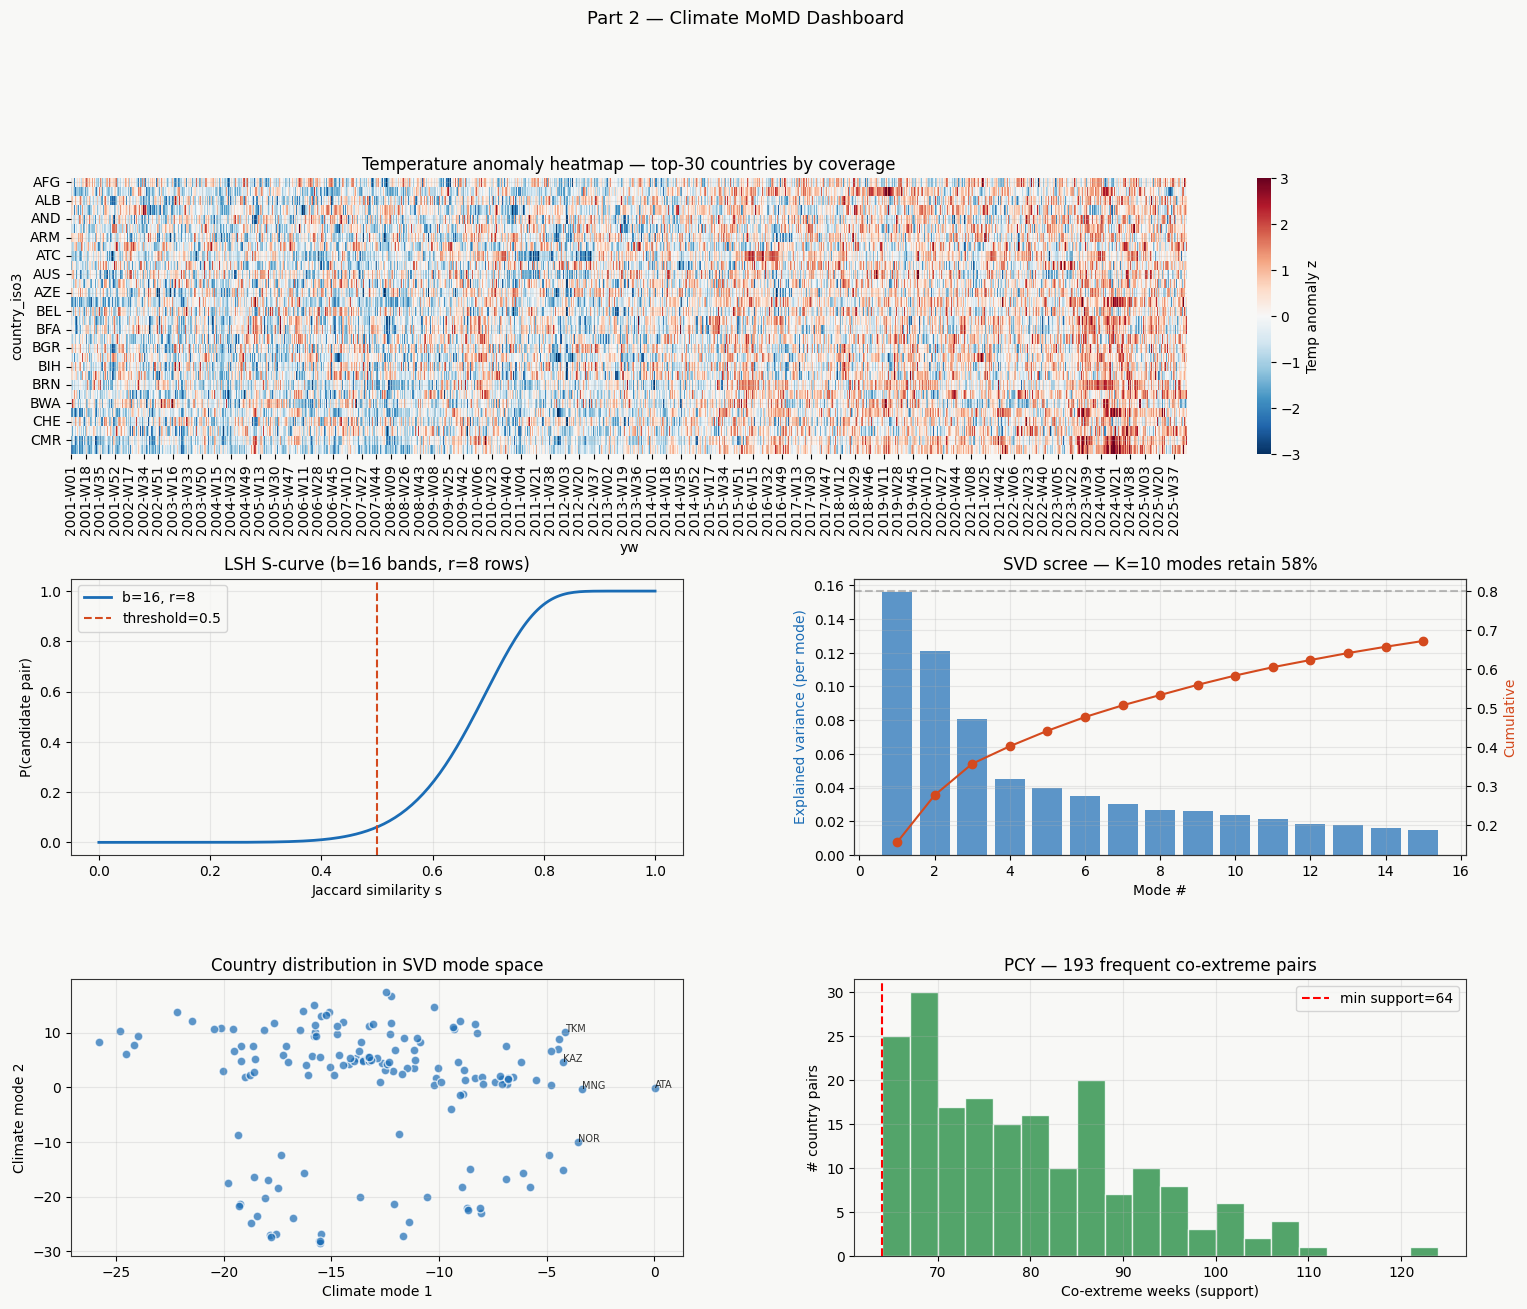

Saved part2_dashboard.png


In [54]:
# ── Comprehensive dashboard (3 panels) ──────────────────────────
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.28)

# (1) Anomaly heatmap top-30
ax = fig.add_subplot(gs[0, :])
top_c = (merged.dropna(subset=[ANOM_COL]).groupby('country_iso3').size().nlargest(30).index)
heat = (merged[merged['country_iso3'].isin(top_c)]
        .assign(yw=lambda x: x['year'].astype(str)+'-W'+x['week'].astype(str).str.zfill(2))
        .pivot_table(index='country_iso3', columns='yw', values=ANOM_COL, aggfunc='mean'))
sns.heatmap(heat, cmap='RdBu_r', center=0, vmin=-3, vmax=3,
            cbar_kws={'label':'Temp anomaly z'}, ax=ax)
ax.set_title('Temperature anomaly heatmap — top-30 countries by coverage')

# (2) LSH S-curve
ax = fig.add_subplot(gs[1, 0])
s_range = np.linspace(0, 1, 200)
p_detect = 1 - (1 - s_range**8)**16
ax.plot(s_range, p_detect, color='#1A6CB5', linewidth=2, label='b=16, r=8')
ax.axvline(0.5, color='#D44A1E', linestyle='--', label='threshold=0.5')
ax.set_xlabel('Jaccard similarity s'); ax.set_ylabel('P(candidate pair)')
ax.set_title('LSH S-curve (b=16 bands, r=8 rows)'); ax.legend()

# (3) SVD scree
ax = fig.add_subplot(gs[1, 1])
ax2 = ax.twinx()
n_show = min(15, len(s))
ax.bar(range(1, n_show+1), expl[:n_show], color='#1A6CB5', alpha=0.7)
ax2.plot(range(1, n_show+1), cum[:n_show], color='#D44A1E', marker='o')
ax2.axhline(0.8, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('Mode #'); ax.set_ylabel('Explained variance (per mode)', color='#1A6CB5')
ax2.set_ylabel('Cumulative', color='#D44A1E')
ax.set_title(f'SVD scree — K={K} modes retain {cum[K-1]:.0%}')

# (4) SVD country scatter mode-1 vs mode-2
ax = fig.add_subplot(gs[2, 0])
ax.scatter(svd_static['mode_1'], svd_static['mode_2'],
           s=40, alpha=0.7, color='#1A6CB5', edgecolor='white')
for _, row in svd_static.nlargest(5, 'mode_1').iterrows():
    ax.annotate(row['country_iso3'], (row['mode_1'], row['mode_2']),
                fontsize=7, alpha=0.8)
ax.set_xlabel('Climate mode 1'); ax.set_ylabel('Climate mode 2')
ax.set_title('Country distribution in SVD mode space')

# (5) PCY frequent co-extreme pairs — support distribution
ax = fig.add_subplot(gs[2, 1])
if len(freq_pairs_df) > 0:
    ax.hist(freq_pairs_df['co_extreme_weeks'], bins=min(20, len(freq_pairs_df)),
            color='#2A8F47', alpha=0.8, edgecolor='white')
    ax.axvline(MIN_SUPPORT, color='red', linestyle='--', label=f'min support={MIN_SUPPORT}')
    ax.set_xlabel('Co-extreme weeks (support)'); ax.set_ylabel('# country pairs')
    ax.set_title(f'PCY — {len(freq_pairs_df)} frequent co-extreme pairs'); ax.legend()
else:
    ax.text(0.5, 0.5, 'No frequent pairs at this support\n(need more data)',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('PCY frequent co-extreme pairs')

plt.suptitle('Part 2 — Climate MoMD Dashboard', fontsize=13, y=1.00)
plt.savefig(OUTPUT_DIR + 'part2_dashboard.png', dpi=130, bbox_inches='tight',
            facecolor=PLOT_BG)
plt.show()
print('Saved part2_dashboard.png')


In [55]:
# ══════════════════════════════════════════════════════════════════
# Final export — single feature file for Part 4 to merge
# Schema: (country_iso3, year, week) + feature columns
# ══════════════════════════════════════════════════════════════════

base_keys = merged[['country_iso3','year','week']].drop_duplicates().copy()
base_keys['year'] = base_keys['year'].astype(int)
base_keys['week'] = base_keys['week'].astype(int)

# ── Merge time-varying features ───────────────────────────────────
part2_ext = (base_keys
    .merge(svd_time,    on=['country_iso3','year','week'], how='left')
    .merge(pcy_feature, on=['country_iso3','year','week'], how='left'))

# ── Merge static per-country features (broadcast) ─────────────────
part2_ext = part2_ext.merge(svd_static, on='country_iso3', how='left')

# ── Fill NaNs ─────────────────────────────────────────────────────
fill_zero = ['pcy_partner_extreme_count'] + contrib_col_names
for col in fill_zero:
    if col in part2_ext.columns:
        part2_ext[col] = part2_ext[col].fillna(0)

# ── Save ──────────────────────────────────────────────────────────
merged.to_parquet(OUTPUT_DIR + 'climate_anomaly_features.parquet', index=False)
similar_pairs.to_parquet(OUTPUT_DIR + 'climate_similarity_pairs.parquet', index=False)
part2_ext.to_parquet(OUTPUT_DIR + 'part2_extended_features.parquet', index=False)

# ── Summary ───────────────────────────────────────────────────────
feature_cols = [c for c in part2_ext.columns if c not in ['country_iso3','year','week']]
svd_static_cols  = [c for c in feature_cols if c.startswith('mode_') and '_contrib' not in c]
svd_contrib_cols = [c for c in feature_cols if '_contrib' in c]
pcy_cols         = [c for c in feature_cols if 'pcy' in c]

print(f'part2_extended_features.parquet : {part2_ext.shape}')
print(f'  Feature columns ({len(feature_cols)}):')
print(f'  [PCY Ch.6]       {len(pcy_cols)} col  | coverage: {part2_ext[pcy_cols[0]].notna().mean():.0%}' if pcy_cols else '')
print(f'  [SVD static Ch.11]  {len(svd_static_cols)} cols | coverage: {part2_ext[svd_static_cols[0]].notna().mean():.0%}' if svd_static_cols else '')
print(f'  [SVD contrib Ch.11] {len(svd_contrib_cols)} cols | coverage: {part2_ext[svd_contrib_cols[0]].notna().mean():.0%}' if svd_contrib_cols else '')

print()
print('='*60)
print('NOTEBOOK 2 — TOTAL OUTPUTS')
print('='*60)
print()
print('Pipeline outputs (dùng cho Part 4):')
print(f'  climate_anomaly_features.parquet   {merged.shape}')
print(f'    └─ anomaly z-scores + lag 1-4 cho mọi (country,year,week)')
print()
print(f'  part2_extended_features.parquet    {part2_ext.shape}')
print(f'    ├─ pcy_partner_extreme_count   (Ch.6 PCY)')
print(f'    ├─ mode_1..mode_K              (Ch.11 SVD static)')
print(f'    └─ mode_k_contrib              (Ch.11 SVD per-week)')
print()
print('Reference outputs:')
print(f'  climate_similarity_pairs.parquet   {similar_pairs.shape}')
print(f'    └─ cặp nước giống nhau (MinHash Jaccard)')
print(f'  part2_dashboard.png                visualization tổng hợp')


part2_extended_features.parquet : (202740, 24)
  Feature columns (21):
  [PCY Ch.6]       1 col  | coverage: 100%
  [SVD static Ch.11]  10 cols | coverage: 100%
  [SVD contrib Ch.11] 10 cols | coverage: 100%

NOTEBOOK 2 — TOTAL OUTPUTS

Pipeline outputs (dùng cho Part 4):
  climate_anomaly_features.parquet   (202740, 35)
    └─ anomaly z-scores + lag 1-4 cho mọi (country,year,week)

  part2_extended_features.parquet    (202740, 24)
    ├─ pcy_partner_extreme_count   (Ch.6 PCY)
    ├─ mode_1..mode_K              (Ch.11 SVD static)
    └─ mode_k_contrib              (Ch.11 SVD per-week)

Reference outputs:
  climate_similarity_pairs.parquet   (1898, 3)
    └─ cặp nước giống nhau (MinHash Jaccard)
  part2_dashboard.png                visualization tổng hợp
